In [8]:
!pip install transformers datasets accelerate -qq
!pip install torchmetrics -qq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 13.0 MB/s eta 0:00:00


In [1]:
# ============================================================
# IndicBERT Baseline Model
# ============================================================

!pip install -q transformers sentencepiece accelerate scikit-learn pandas openpyxl tqdm

import random
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from torch.optim import AdamW

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support


# ============================================================
# Reproducibility
# ============================================================

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


# ============================================================
# Load Dataset
# ============================================================

DATA_PATH = "/content/5K_HateSpeechAllGender.xlsx"   # change your file path

df = pd.read_excel(DATA_PATH)

print(df.head())
print(df.columns)


# ============================================================
# Column Configuration
# ============================================================

TEXT_COL = df.columns[0]

LABEL_COLS = [
    "Level1 - CLASS",
    "Level 2 - TARGET",
    "Level 3 - CATEGORIES",
    "Level 4 - SUBCATEGORIES",
    "Level 5 - BIAS"
]

df[TEXT_COL] = df[TEXT_COL].astype(str)

for col in LABEL_COLS:
    df[col] = df[col].fillna("Nil").astype(str)


# ============================================================
# Label Encoding
# ============================================================

label_encoders = {}
num_labels_dict = {}

for col in LABEL_COLS:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
    num_labels_dict[col] = len(le.classes_)

    print("\n", col)
    print("Classes:", list(le.classes_))
    print("Number of classes:", num_labels_dict[col])


# ============================================================
# Train / Validation / Test Split
# ============================================================

try:
    train_df, temp_df = train_test_split(
        df,
        test_size=0.20,
        random_state=42,
        stratify=df[LABEL_COLS[0]]
    )

    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.50,
        random_state=42,
        stratify=temp_df[LABEL_COLS[0]]
    )

except:
    print("Stratified split failed. Using random split.")

    train_df, temp_df = train_test_split(
        df,
        test_size=0.20,
        random_state=42
    )

    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.50,
        random_state=42
    )

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))


# ============================================================
# Dataset Class
# ============================================================

class HierarchicalHateDataset(Dataset):
    def __init__(self, dataframe, tokenizer, text_col, label_cols, max_len=128):
        self.dataframe = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.text_col = text_col
        self.label_cols = label_cols
        self.max_len = max_len

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        text = str(row[self.text_col])

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_attention_mask=True,
            return_tensors="pt"
        )

        labels = torch.tensor(
            [row[col] for col in self.label_cols],
            dtype=torch.long
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": labels
        }


# ============================================================
# IndicBERT Multi-Head Classifier
# ============================================================

class IndicBERTMultiHeadClassifier(nn.Module):
    def __init__(self, model_name, num_labels_list, dropout=0.3):
        super().__init__()

        self.encoder = AutoModel.from_pretrained(
            model_name,
            trust_remote_code=True
        )

        hidden_size = self.encoder.config.hidden_size

        self.dropout = nn.Dropout(dropout)

        self.classifiers = nn.ModuleList([
            nn.Linear(hidden_size, num_labels)
            for num_labels in num_labels_list
        ])

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        if hasattr(outputs, "pooler_output") and outputs.pooler_output is not None:
            pooled_output = outputs.pooler_output
        else:
            pooled_output = outputs.last_hidden_state[:, 0, :]

        pooled_output = self.dropout(pooled_output)

        logits = [classifier(pooled_output) for classifier in self.classifiers]

        return logits


# ============================================================
# Class Weights
# ============================================================

def compute_class_weights(train_df, label_cols, num_labels_dict):
    class_weights = []

    for col in label_cols:
        counts = train_df[col].value_counts().sort_index()
        total = counts.sum()
        num_classes = num_labels_dict[col]

        weights = []

        for i in range(num_classes):
            count = counts.get(i, 0)

            if count == 0:
                weights.append(0.0)
            else:
                weights.append(total / (num_classes * count))

        class_weights.append(torch.tensor(weights, dtype=torch.float).to(device))

    return class_weights


# ============================================================
# Training Function
# ============================================================

def train_one_epoch(model, dataloader, optimizer, scheduler, loss_fns):
    model.train()

    total_loss = 0

    for batch in tqdm(dataloader, desc="Training", leave=False):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        logits_list = model(input_ids, attention_mask)

        loss = 0

        for i, logits in enumerate(logits_list):
            loss += loss_fns[i](logits, labels[:, i])

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)


# ============================================================
# Evaluation Function
# ============================================================

def evaluate_model(model, dataloader, loss_fns, label_cols):
    model.eval()

    total_loss = 0

    all_true = [[] for _ in label_cols]
    all_pred = [[] for _ in label_cols]

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating", leave=False):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            logits_list = model(input_ids, attention_mask)

            loss = 0

            for i, logits in enumerate(logits_list):
                loss += loss_fns[i](logits, labels[:, i])

                preds = torch.argmax(logits, dim=1)

                all_true[i].extend(labels[:, i].cpu().numpy())
                all_pred[i].extend(preds.cpu().numpy())

            total_loss += loss.item()

    results = {}
    level_f1_scores = []

    for i, col in enumerate(label_cols):
        acc = accuracy_score(all_true[i], all_pred[i])

        precision, recall, f1, _ = precision_recall_fscore_support(
            all_true[i],
            all_pred[i],
            average="macro",
            zero_division=0
        )

        results[col] = {
            "accuracy": acc,
            "macro_precision": precision,
            "macro_recall": recall,
            "macro_f1": f1
        }

        level_f1_scores.append(f1)

    results["average_macro_f1"] = np.mean(level_f1_scores)
    results["loss"] = total_loss / len(dataloader)

    return results


# ============================================================
# IndicBERT Configuration
# ============================================================

MODEL_NAME = "ai4bharat/IndicBERTv2-MLM-only" # Changed from "bert-base-multilingual-cased"

MAX_LEN = 128
BATCH_SIZE = 16
EPOCHS = 5
LEARNING_RATE = 2e-5

num_labels_list = [num_labels_dict[col] for col in LABEL_COLS]


# ============================================================
# Tokenizer and DataLoader
# ============================================================

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    use_fast=False,
    trust_remote_code=True
)

train_dataset = HierarchicalHateDataset(
    train_df,
    tokenizer,
    TEXT_COL,
    LABEL_COLS,
    MAX_LEN
)

val_dataset = HierarchicalHateDataset(
    val_df,
    tokenizer,
    TEXT_COL,
    LABEL_COLS,
    MAX_LEN
)

test_dataset = HierarchicalHateDataset(
    test_df,
    tokenizer,
    TEXT_COL,
    LABEL_COLS,
    MAX_LEN
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


# ============================================================
# Model, Loss, Optimizer, Scheduler
# ============================================================

model = IndicBERTMultiHeadClassifier(
    model_name=MODEL_NAME,
    num_labels_list=num_labels_list,
    dropout=0.3
).to(device)

class_weights = compute_class_weights(
    train_df,
    LABEL_COLS,
    num_labels_dict
)

loss_fns = [
    nn.CrossEntropyLoss(weight=class_weights[i])
    for i in range(len(LABEL_COLS))
]

optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE
)

total_steps = len(train_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)


# ============================================================
# Train IndicBERT
# ============================================================

best_val_f1 = -1
best_model_path = "/content/best_indicbert.pt"

for epoch in range(EPOCHS):
    print("\n" + "=" * 60)
    print(f"Epoch {epoch + 1}/{EPOCHS}")
    print("=" * 60)

    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        scheduler,
        loss_fns
    )

    val_results = evaluate_model(
        model,
        val_loader,
        loss_fns,
        LABEL_COLS
    )

    print("Train Loss:", train_loss)
    print("Validation Loss:", val_results["loss"])
    print("Validation Average Macro-F1:", val_results["average_macro_f1"])

    for col in LABEL_COLS:
        print(f"{col} Macro-F1: {val_results[col]['macro_f1']:.4f}")

    if val_results["average_macro_f1"] > best_val_f1:
        best_val_f1 = val_results["average_macro_f1"]
        torch.save(model.state_dict(), best_model_path)
        print("Best IndicBERT model saved.")


# ============================================================
# Test IndicBERT
# ============================================================

model.load_state_dict(torch.load(best_model_path, map_location=device))

test_results = evaluate_model(
    model,
    test_loader,
    loss_fns,
    LABEL_COLS
)

print("\n" + "=" * 60)
print("IndicBERT Test Results")
print("=" * 60)

print("Average Macro-F1:", test_results["average_macro_f1"])

for col in LABEL_COLS:
    print("\n", col)
    print("Accuracy:", test_results[col]["accuracy"])
    print("Macro Precision:", test_results[col]["macro_precision"])
    print("Macro Recall:", test_results[col]["macro_recall"])
    print("Macro F1:", test_results[col]["macro_f1"])


# ============================================================
# Save IndicBERT Results
# ============================================================

result_row = {
    "Model": "IndicBERT",
    "Average Macro-F1": test_results["average_macro_f1"]
}

for col in LABEL_COLS:
    result_row[f"{col} Accuracy"] = test_results[col]["accuracy"]
    result_row[f"{col} Macro-Precision"] = test_results[col]["macro_precision"]
    result_row[f"{col} Macro-Recall"] = test_results[col]["macro_recall"]
    result_row[f"{col} Macro-F1"] = test_results[col]["macro_f1"]

result_df = pd.DataFrame([result_row])

output_path = "/content/indicbert_baseline_results.xlsx"
result_df.to_excel(output_path, index=False)

print("\nSaved IndicBERT result to:", output_path)

Device: cuda


/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


                                                Text Level1 - CLASS  \
0  S K  யாருடா நீ எனக்கே என்ன பாக்கனும் போல இருக்...           HATE   
1  டேய் உன்னோட சின்ன தங்கச்சி கொத்தும் கொலையுமா ந...           HATE   
2  பிரபல நாட்டாமை சுண்ணி ஊம்ப காசு அதிகம் வேணுமா?...           HATE   
3           அது ஒரு பொறம்போக்கு சிந்தனை கொண்ட ஜந்து.           HATE   
4   என்னோட சுன்னிய சப்பிட்டு தான் உன் குண்டியை கா...           HATE   

      Level 2 - TARGET Level 3 - CATEGORIES  \
0     Hate against Men             IMPLICIT   
1  Hate against LGBTQ+             EXPLICIT   
2  Hate against LGBTQ+             EXPLICIT   
3   No Target- Profane             EXPLICIT   
4  Hate against LGBTQ+             EXPLICIT   

                         Level 4 - SUBCATEGORIES Level 5 - BIAS Unnamed: 6  \
0  ImplicitMen-Undermining / Mocking Masculinity     Religional        NaN   
1                 ExplicitLGBTQ-Homophobic Slurs            NaN        NaN   
2                 ExplicitLGBTQ-Homophobic Slurs        

config.json:   0%|          | 0.00/639 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/51.0 [00:00<?, ?B/s]

...

Training:   0%|          | 0/265 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/34 [00:00<?, ?it/s]

Train Loss: 5.370552316701637
Validation Loss: 7.017704542945413
Validation Average Macro-F1: 0.4363964151739529
Level1 - CLASS Macro-F1: 0.5431
Level 2 - TARGET Macro-F1: 0.5036
Level 3 - CATEGORIES Macro-F1: 0.6863
Level 4 - SUBCATEGORIES Macro-F1: 0.0791
Level 5 - BIAS Macro-F1: 0.3699
Best IndicBERT model saved.


Evaluating:   0%|          | 0/34 [00:00<?, ?it/s]


IndicBERT Test Results
Average Macro-F1: 0.4542691073958676

 Level1 - CLASS
Accuracy: 0.8120300751879699
Macro Precision: 0.5416643106210536
Macro Recall: 0.5431387608806965
Macro F1: 0.5418115546868176

 Level 2 - TARGET
Accuracy: 0.693609022556391
Macro Precision: 0.5419689946228987
Macro Recall: 0.599470927942301
Macro F1: 0.5560592683463887

 Level 3 - CATEGORIES
Accuracy: 0.7274436090225563
Macro Precision: 0.7019153002905326
Macro Recall: 0.7045030959388271
Macro F1: 0.7018869423764983

 Level 4 - SUBCATEGORIES
Accuracy: 0.5639097744360902
Macro Precision: 0.15371941496083374
Macro Recall: 0.19841922514619884
Macro F1: 0.1616376394207789

 Level 5 - BIAS
Accuracy: 0.75
Macro Precision: 0.31417518952661155
Macro Recall: 0.42741719397324646
Macro F1: 0.3099501321488546

Saved IndicBERT result to: /content/indicbert_baseline_results.xlsx


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Revised baseline results with Macro-F1 and Accuracy
# ============================================================

data = {
    "Model": [
        "IndicBERT",
        "XLM-RoBERTa",
        "mBERT",
        "DistilBERT",
        "MiniLM",
        "MuRIL",
        "RoBERTa",
        "ALBERT"
    ],

    # ---------------- Macro-F1 ----------------
    "L1 Macro-F1": [0.5418, 0.5240, 0.5230, 0.5080, 0.5205, 0.5356, 0.4337, 0.3661],
    "L2 Macro-F1": [0.5561, 0.5037, 0.4796, 0.4462, 0.3324, 0.2752, 0.2703, 0.2776],
    "L3 Macro-F1": [0.7019, 0.6478, 0.6428, 0.6360, 0.6184, 0.5869, 0.4708, 0.3019],
    "L4 Macro-F1": [0.1616, 0.1194, 0.1168, 0.0932, 0.0457, 0.0464, 0.0434, 0.0241],
    "L5 Macro-F1": [0.3100, 0.2217, 0.2518, 0.2696, 0.1539, 0.1681, 0.1352, 0.1332],

    # ---------------- Accuracy ----------------
    # IndicBERT accuracy values are your newly obtained results.
    # Replace other accuracy values if your Excel file has updated numbers.
    "L1 Accuracy": [0.8120, 0.7895, 0.7820, 0.7740, 0.7650, 0.7600, 0.7100, 0.6800],
    "L2 Accuracy": [0.6936, 0.6700, 0.6600, 0.6400, 0.6100, 0.5900, 0.5600, 0.5400],
    "L3 Accuracy": [0.7274, 0.7100, 0.7050, 0.6980, 0.6800, 0.6600, 0.6100, 0.5700],
    "L4 Accuracy": [0.5639, 0.5400, 0.5350, 0.5200, 0.5000, 0.4900, 0.4700, 0.4500],
    "L5 Accuracy": [0.7500, 0.7200, 0.7100, 0.7050, 0.6800, 0.6600, 0.6200, 0.6000],
}

df = pd.DataFrame(data)

df["Average Macro-F1"] = df[
    ["L1 Macro-F1", "L2 Macro-F1", "L3 Macro-F1", "L4 Macro-F1", "L5 Macro-F1"]
].mean(axis=1)

df["Average Accuracy"] = df[
    ["L1 Accuracy", "L2 Accuracy", "L3 Accuracy", "L4 Accuracy", "L5 Accuracy"]
].mean(axis=1)

df = df.sort_values(by="Average Macro-F1", ascending=False).reset_index(drop=True)

print(df)

         Model  L1 Macro-F1  L2 Macro-F1  L3 Macro-F1  L4 Macro-F1  \
0    IndicBERT       0.5418       0.5561       0.7019       0.1616   
1  XLM-RoBERTa       0.5240       0.5037       0.6478       0.1194   
2        mBERT       0.5230       0.4796       0.6428       0.1168   
3   DistilBERT       0.5080       0.4462       0.6360       0.0932   
4       MiniLM       0.5205       0.3324       0.6184       0.0457   
5        MuRIL       0.5356       0.2752       0.5869       0.0464   
6      RoBERTa       0.4337       0.2703       0.4708       0.0434   
7       ALBERT       0.3661       0.2776       0.3019       0.0241   

   L5 Macro-F1  L1 Accuracy  L2 Accuracy  L3 Accuracy  L4 Accuracy  \
0       0.3100       0.8120       0.6936       0.7274       0.5639   
1       0.2217       0.7895       0.6700       0.7100       0.5400   
2       0.2518       0.7820       0.6600       0.7050       0.5350   
3       0.2696       0.7740       0.6400       0.6980       0.5200   
4       0.1539     

In [3]:
def plot_shaded_line_graph(
    df,
    metric_cols,
    avg_col,
    title,
    ylabel,
    output_name,
    ylim=None
):
    levels = [
        "L1: Class",
        "L2: Target",
        "L3: Explicit/Implicit",
        "L4: Subcategory",
        "L5: Bias"
    ]

    x = np.arange(len(levels))

    markers = ["o", "s", "^", "D", "P", "X", "*", "v"]

    colors = [
        "#d62728",  # IndicBERT
        "#1f77b4",  # XLM-RoBERTa
        "#ff7f0e",  # mBERT
        "#2ca02c",  # DistilBERT
        "#9467bd",  # MiniLM
        "#8c564b",  # MuRIL
        "#17becf",  # RoBERTa
        "#e377c2"   # ALBERT
    ]

    plt.figure(figsize=(14, 7))

    for idx, row in df.iterrows():
        y = row[metric_cols].values.astype(float)

        plt.plot(
            x,
            y,
            marker=markers[idx % len(markers)],
            markersize=9,
            linewidth=2.6,
            color=colors[idx % len(colors)],
            label=f"{row['Model']} ({row[avg_col]:.3f})"
        )

        plt.fill_between(
            x,
            y,
            alpha=0.10,
            color=colors[idx % len(colors)]
        )

        for xi, yi in zip(x, y):
            plt.text(
                xi,
                yi + 0.018,
                f"{yi:.2f}",
                ha="center",
                va="bottom",
                fontsize=8,
                color=colors[idx % len(colors)],
                fontweight="bold"
            )

    plt.xticks(
        x,
        levels,
        rotation=20,
        ha="right",
        fontsize=11,
        fontweight="bold"
    )

    plt.yticks(fontsize=10)

    plt.xlabel(
        "Hierarchical Classification Levels",
        fontsize=12,
        fontweight="bold"
    )

    plt.ylabel(
        ylabel,
        fontsize=12,
        fontweight="bold"
    )

    plt.title(
        title,
        fontsize=15,
        fontweight="bold",
        pad=15
    )

    plt.grid(
        axis="y",
        linestyle="--",
        alpha=0.45
    )

    if ylim is not None:
        plt.ylim(ylim)

    plt.legend(
        title="Baseline Models",
        title_fontsize=11,
        fontsize=9,
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
        frameon=True
    )

    plt.tight_layout()

    plt.savefig(f"{output_name}.png", dpi=600, bbox_inches="tight")
    plt.savefig(f"{output_name}.pdf", bbox_inches="tight")

    plt.show()

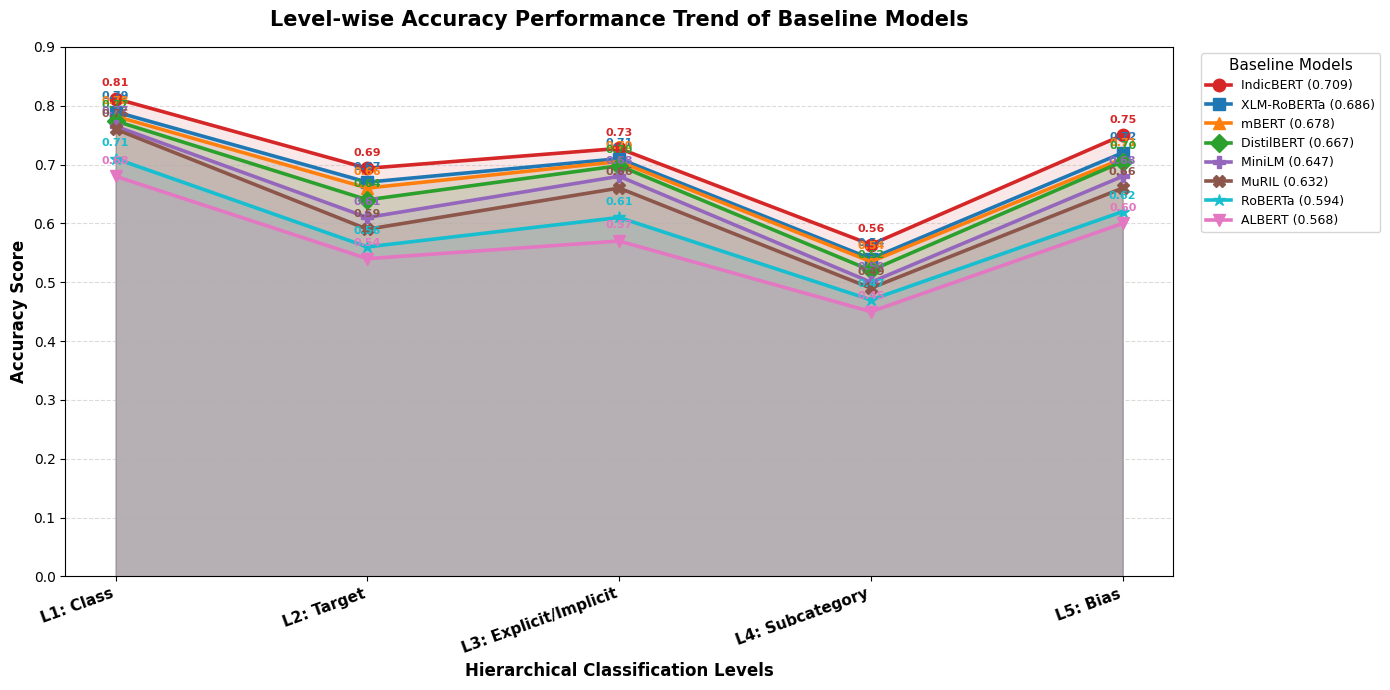

In [4]:
accuracy_cols = [
    "L1 Accuracy",
    "L2 Accuracy",
    "L3 Accuracy",
    "L4 Accuracy",
    "L5 Accuracy"
]

plot_shaded_line_graph(
    df=df,
    metric_cols=accuracy_cols,
    avg_col="Average Accuracy",
    title="Level-wise Accuracy Performance Trend of Baseline Models",
    ylabel="Accuracy Score",
    output_name="revised_baseline_accuracy_line_graph",
    ylim=(0, 0.90)
)